# FedProx μ Selection Pilot

**Purpose.** Select one FedProx proximal coefficient before the
balanced main benchmark, using validation performance only.

## Research question

> Among the prespecified candidates μ ∈ {0.01, 0.1, 1.0}, which
> value provides the strongest and most stable late-round validation
> accuracy under severe label skew?

The pilot uses label skew α=0.1 because client objectives diverge
strongly in this setting, making the proximal term consequential.
Seeds 42, 43, and 44 measure sensitivity to both the client
partition and model initialization.

This notebook reads the immutable nine-run archive, independently
recomputes the selection, and verifies the saved decision. It does
not retrain models.


## 1. Imports and visual style


In [1]:
from __future__ import annotations

import json
import os
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

MU_CANDIDATES = [0.01, 0.1, 1.0]
SEEDS = [42, 43, 44]
SELECTION_ROUNDS = [16, 17, 18, 19, 20]
TIE_TOLERANCE = 0.0025
COLORS = {
    0.01: "#4C78A8",
    0.1: "#F58518",
    1.0: "#54A24B",
}


## 2. Locate and validate the pilot archive

Set `FEDPROX_PILOT_ARCHIVE` if the ZIP is outside the project,
notebook, `artifacts/`, or Kaggle working directories. The archive
must contain nine completed runs and the three saved selection
records.


In [2]:
ARCHIVE_NAME = "fedprox_mu_pilot_v1_complete.zip"

explicit_archive = os.environ.get("FEDPROX_PILOT_ARCHIVE")
candidates = [
    Path(explicit_archive) if explicit_archive else None,
    Path.cwd() / ARCHIVE_NAME,
    Path.cwd().parent / ARCHIVE_NAME,
    Path.cwd() / "artifacts" / ARCHIVE_NAME,
    Path.cwd().parent / "artifacts" / ARCHIVE_NAME,
    Path("/kaggle/working") / ARCHIVE_NAME,
]
archive_path = next(
    (path.resolve() for path in candidates if path and path.exists()),
    None,
)

if archive_path is None:
    kaggle_matches = list(
        Path("/kaggle/input").glob(f"**/{ARCHIVE_NAME}")
    ) if Path("/kaggle/input").exists() else []
    archive_path = kaggle_matches[0] if kaggle_matches else None

if archive_path is None:
    raise FileNotFoundError(
        f"Could not locate {ARCHIVE_NAME}. Set "
        "FEDPROX_PILOT_ARCHIVE to its absolute path."
    )

analysis_root = Path(
    os.environ.get(
        "FEDPROX_PILOT_ANALYSIS_ROOT",
        Path.cwd() / "fedprox_mu_pilot_analysis",
    )
)
extracted_root = analysis_root / "archive"
figure_directory = analysis_root / "figures"
table_directory = analysis_root / "tables"
extracted_root.mkdir(parents=True, exist_ok=True)
figure_directory.mkdir(parents=True, exist_ok=True)
table_directory.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(archive_path) as archive:
    corrupt_member = archive.testzip()
    if corrupt_member is not None:
        raise RuntimeError(f"Corrupt ZIP member: {corrupt_member}")
    archive.extractall(extracted_root)

run_directories = sorted(
    path for path in (extracted_root / "runs").iterdir()
    if path.is_dir()
)
completion_markers = list(
    (extracted_root / "runs").glob("*/COMPLETED.json")
)

assert len(run_directories) == 9
assert len(completion_markers) == 9
print("Archive:", archive_path)
print("Completed pilot runs:", len(completion_markers))


Archive: D:\HKU\New folder\federated-learning-under-heterogeneity-final\federated-learning-under-heterogeneity\artifacts\fedprox_mu_pilot_v1_complete.zip
Completed pilot runs: 9


## 3. Reconstruct the pilot tables from per-run artifacts

The aggregate selection is recomputed from each run's
`validation_by_round.csv`. The μ value and final held-out metrics
come from that run's `summary.json`; directory names are not parsed
as data.


In [3]:
validation_frames = []
summary_rows = []

for run_directory in run_directories:
    run_summary = json.loads(
        (run_directory / "summary.json").read_text(encoding="utf-8")
    )
    run_validation = pd.read_csv(
        run_directory / "validation_by_round.csv"
    )
    run_validation.insert(2, "mu", float(run_summary["mu"]))
    run_validation.insert(0, "run_key", run_directory.name)

    validation_frames.append(run_validation)
    summary_rows.append({"run_key": run_directory.name, **run_summary})

validation_by_round = pd.concat(
    validation_frames,
    ignore_index=True,
)
run_summary = pd.DataFrame(summary_rows)

assert set(run_summary["algorithm"]) == {"fedprox"}
assert set(run_summary["mode"]) == {"label_skew"}
assert np.allclose(run_summary["alpha"], 0.1)
assert set(run_summary["seed"]) == set(SEEDS)
assert set(run_summary["mu"]) == set(MU_CANDIDATES)
assert run_summary.groupby(["seed", "mu"]).size().eq(1).all()
assert validation_by_round.groupby("run_key").size().eq(21).all()
assert all(
    set(frame["round"]) == set(range(21))
    for _, frame in validation_by_round.groupby("run_key")
)

round_zero = validation_by_round.query("round == 0")
round_zero_span = round_zero.groupby("seed")[
    "weighted_accuracy"
].agg(lambda values: values.max() - values.min())
assert np.allclose(round_zero_span, 0.0)

protocol_audit = pd.Series({
    "runs": len(run_summary),
    "seeds": run_summary["seed"].nunique(),
    "mu candidates": run_summary["mu"].nunique(),
    "rounds per run": 21,
    "maximum round-zero difference": round_zero_span.max(),
}, name="value")
display(protocol_audit.to_frame())


,value
runs,9.0
seeds,3.0
mu candidates,3.0
rounds per run,21.0
maximum round-zero difference,0.0


## 4. Prespecified selection rule

For candidate μ and seed s, define the late-round score

\[
q_{\mu,s} = \frac{1}{5}\sum_{t=16}^{20}
\operatorname{ValidationAccuracy}_{\mu,s,t}.
\]

We then compute the cross-seed mean and sample standard deviation of
\(q_{\mu,s}\).

1. Find the highest cross-seed mean.
2. Retain every μ within **0.0025** of that mean.
3. Among eligible candidates, select the smallest cross-seed
   standard deviation.
4. If stability is tied, select the smaller μ.

Averaging rounds 16–20 reduces sensitivity to a single noisy final
round. The tolerance prevents a negligible mean difference from
overriding a meaningful stability difference. Only validation data
enter this rule; global and local test outcomes remain untouched.


In [4]:
scores_by_seed = (
    validation_by_round[
        validation_by_round["round"].isin(SELECTION_ROUNDS)
    ]
    .groupby(["mu", "seed"], as_index=False)["weighted_accuracy"]
    .mean()
    .rename(columns={
        "weighted_accuracy": "tail_validation_accuracy"
    })
    .sort_values(["mu", "seed"], ignore_index=True)
)

scores_by_mu = (
    scores_by_seed
    .groupby("mu", as_index=False)["tail_validation_accuracy"]
    .agg(
        mean_validation_accuracy="mean",
        std_validation_accuracy="std",
        num_seeds="size",
    )
    .sort_values("mu", ignore_index=True)
)

best_mean = scores_by_mu["mean_validation_accuracy"].max()
scores_by_mu["within_tolerance"] = (
    scores_by_mu["mean_validation_accuracy"]
    >= best_mean - TIE_TOLERANCE
)

eligible = scores_by_mu[scores_by_mu["within_tolerance"]]
selected_mu = float(
    eligible.sort_values(
        ["std_validation_accuracy", "mu"],
        ascending=[True, True],
    ).iloc[0]["mu"]
)
scores_by_mu["selected"] = scores_by_mu["mu"].eq(selected_mu)

assert selected_mu == 0.01
display(scores_by_seed.round(6))
display(scores_by_mu.round(6))

scores_by_seed.to_csv(
    table_directory / "fedprox_mu_scores_by_seed.csv",
    index=False,
)
scores_by_mu.to_csv(
    table_directory / "fedprox_mu_scores_by_mu.csv",
    index=False,
)


,mu,seed,tail_validation_accuracy
0,0.01,42,0.868433
1,0.01,43,0.837333
2,0.01,44,0.829300
3,0.10,42,0.866767
4,0.10,43,0.835567
5,0.10,44,0.826567
6,1.00,42,0.848700
7,1.00,43,0.814633
8,1.00,44,0.804133


,mu,mean_validation_accuracy,std_validation_accuracy,num_seeds,within_tolerance,selected
0,0.01,0.845022,0.020669,3,True,True
1,0.10,0.842967,0.021097,3,True,False
2,1.00,0.822489,0.023299,3,False,False


## 5. Verify the saved selection records

Agreement between the independent recomputation and the archive's
saved CSV/JSON records protects against an accidental manual choice
or a later change to the selection rule.


In [5]:
saved_scores_by_seed = pd.read_csv(
    extracted_root / "fedprox_mu_scores_by_seed.csv"
).sort_values(["mu", "seed"], ignore_index=True)
saved_scores_by_mu = pd.read_csv(
    extracted_root / "fedprox_mu_scores_by_mu.csv"
).sort_values("mu", ignore_index=True)
saved_selection = json.loads(
    (extracted_root / "selected_mu.json").read_text(encoding="utf-8")
)

pd.testing.assert_frame_equal(
    scores_by_seed,
    saved_scores_by_seed,
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)
pd.testing.assert_frame_equal(
    scores_by_mu[
        [
            "mu",
            "mean_validation_accuracy",
            "std_validation_accuracy",
            "num_seeds",
            "selected",
        ]
    ],
    saved_scores_by_mu,
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)

assert saved_selection["selected_mu"] == selected_mu
assert saved_selection["seeds"] == SEEDS
assert saved_selection["mu_candidates"] == MU_CANDIDATES
assert saved_selection["selection_rounds"] == SELECTION_ROUNDS
assert saved_selection["tie_tolerance"] == TIE_TOLERANCE

display(pd.Series(saved_selection, name="saved value").to_frame())


,saved value
selected_mu,0.01
seeds,"[42, 43, 44]"
mu_candidates,"[0.01, 0.1, 1.0]"
selection_rounds,"[16, 17, 18, 19, 20]"
tie_tolerance,0.0025
git_commit,644b4a53c0a4bfd2e1dbbdaef83e2f695db09e49


## 6. Cross-seed convergence

Lines show mean weighted validation accuracy across the three seeds;
shading shows ±1 sample standard deviation. Round-zero equality
confirms that μ candidates share the same initial model and
validation data within each seed.


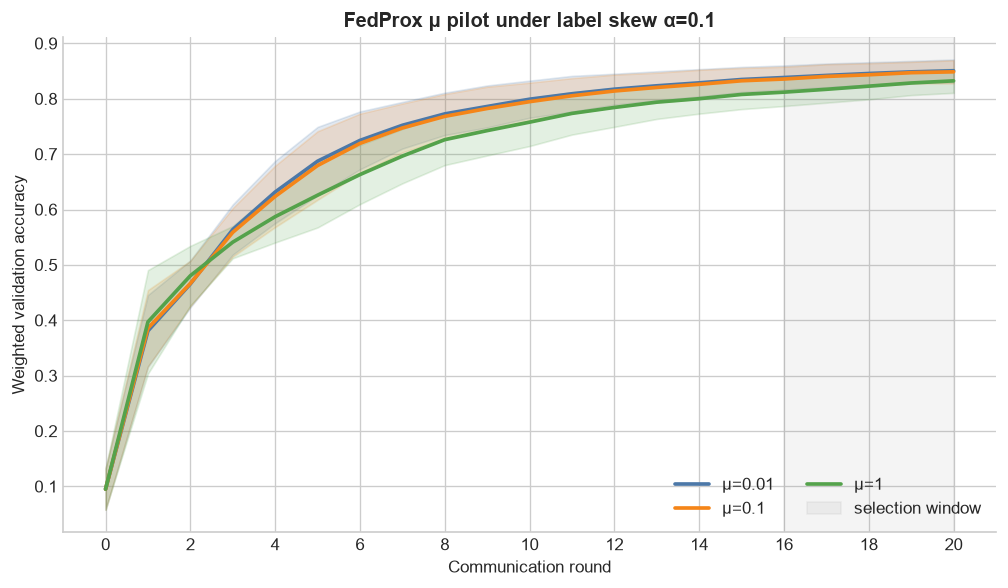

In [6]:
convergence = (
    validation_by_round
    .groupby(["mu", "round"])["weighted_accuracy"]
    .agg(mean="mean", std="std")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8.5, 5))
for mu in MU_CANDIDATES:
    subset = convergence[convergence["mu"].eq(mu)]
    rounds = subset["round"].to_numpy()
    mean = subset["mean"].to_numpy()
    std = subset["std"].to_numpy()
    ax.plot(
        rounds,
        mean,
        linewidth=2.2,
        color=COLORS[mu],
        label=f"μ={mu:g}",
    )
    ax.fill_between(
        rounds,
        mean - std,
        mean + std,
        color=COLORS[mu],
        alpha=0.16,
    )

ax.axvspan(16, 20, color="#777777", alpha=0.08, label="selection window")
ax.set_xlabel("Communication round")
ax.set_ylabel("Weighted validation accuracy")
ax.set_title("FedProx μ pilot under label skew α=0.1")
ax.set_xticks(range(0, 21, 2))
ax.legend(ncol=2, loc="lower right")
fig.tight_layout()
fig.savefig(
    figure_directory / "fedprox_mu_validation_convergence.png",
    bbox_inches="tight",
)
plt.show()


## 7. Mean–stability trade-off

The horizontal line marks the eligibility boundary: the best mean
minus 0.0025. Both μ=0.01 and μ=0.1 remain eligible, so the lower
across-seed standard deviation selects μ=0.01. μ=1.0 is neither
competitive in mean performance nor stability.


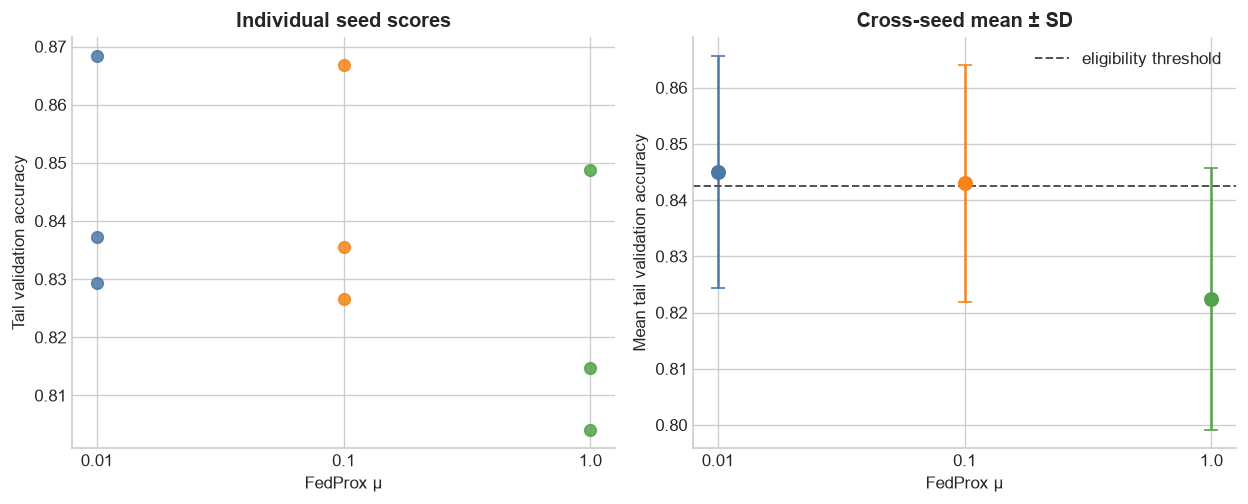

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))

for mu in MU_CANDIDATES:
    seed_subset = scores_by_seed[scores_by_seed["mu"].eq(mu)]
    axes[0].scatter(
        [mu] * len(seed_subset),
        seed_subset["tail_validation_accuracy"],
        s=48,
        color=COLORS[mu],
        alpha=0.85,
    )
axes[0].set_xscale("log")
axes[0].set_xticks(MU_CANDIDATES, ["0.01", "0.1", "1.0"])
axes[0].set_xlabel("FedProx μ")
axes[0].set_ylabel("Tail validation accuracy")
axes[0].set_title("Individual seed scores")

for _, row in scores_by_mu.iterrows():
    mu = float(row["mu"])
    axes[1].errorbar(
        mu,
        row["mean_validation_accuracy"],
        yerr=row["std_validation_accuracy"],
        fmt="o",
        markersize=8,
        capsize=4,
        color=COLORS[mu],
    )
axes[1].axhline(
    best_mean - TIE_TOLERANCE,
    color="#555555",
    linestyle="--",
    linewidth=1.2,
    label="eligibility threshold",
)
axes[1].set_xscale("log")
axes[1].set_xticks(MU_CANDIDATES, ["0.01", "0.1", "1.0"])
axes[1].set_xlabel("FedProx μ")
axes[1].set_ylabel("Mean tail validation accuracy")
axes[1].set_title("Cross-seed mean ± SD")
axes[1].legend()

fig.tight_layout()
fig.savefig(
    figure_directory / "fedprox_mu_mean_stability_tradeoff.png",
    bbox_inches="tight",
)
plt.show()


## 8. Held-out outcomes: characterization only

The table below is inspected **after** μ has been selected. Global
and local test metrics did not enter candidate ranking. They are
reported only to characterize the frozen decision and must not be
used to retroactively change it.


In [8]:
held_out_summary = (
    run_summary
    .groupby("mu")
    .agg(
        global_test_mean=("global_test_accuracy", "mean"),
        global_test_std=("global_test_accuracy", "std"),
        local_test_mean=("local_test_weighted_accuracy", "mean"),
        worst_client_mean=(
            "local_test_worst_client_accuracy",
            "mean",
        ),
        runtime_mean_seconds=("runtime_seconds", "mean"),
    )
    .reindex(MU_CANDIDATES)
)
display(held_out_summary.round(4))
held_out_summary.to_csv(
    table_directory / "held_out_characterization.csv"
)


,global_test_mean,global_test_std,local_test_mean,worst_client_mean,runtime_mean_seconds
mu,,,,,
0.01,0.8599,0.0264,0.8551,0.7608,126.9903
0.10,0.8581,0.0261,0.8529,0.7581,126.7725
1.00,0.8401,0.0274,0.8351,0.7339,126.8617


## Decision

**Selected value: μ=0.01.**

μ=0.01 achieved the highest late-round validation mean
(0.84502). μ=0.1 was within the prespecified 0.0025 tolerance but
had slightly higher across-seed variation, so the stability rule
retained μ=0.01. μ=1.0 was clearly worse.

This decision was frozen before the 63-run main benchmark in
Notebook 9. It supports the scoped statement:

> Among the three prespecified candidates under label skew α=0.1,
> 20 rounds, five fully participating clients, and one local epoch,
> μ=0.01 provided the best stability-aware validation result.

It does **not** establish that μ=0.01 is universally optimal, nor
does it compare FedProx against FedAvg or SCAFFOLD. Those questions
belong to the balanced main benchmark.

## Limitations

- Only three μ values and three seeds are included.
- Tuning uses one severe label-skew condition rather than every
  heterogeneity family.
- The selection is specific to MNIST, this MLP, and the fixed
  training budget.
- The tolerance and stability rule are design choices and must be
  declared before examining the main benchmark.

Figures and compact recomputed tables are written to
`fedprox_mu_pilot_analysis/`; the input archive remains unchanged.
